# Registered geographic probability sample

**Physical question.** Where did the frozen, inventory-only design place the 96 reporting cells that will later support glacier- and permafrost-proximity equivalent-area totals? The frame uses RGI 7 glacier outlines, not present-day glacier extent. This notebook describes the sampling frame and draw only. It opens no DEM, PZI, event, or climate value.

In [1]:
from pathlib import Path
import csv, hashlib
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np
root = Path('..')
frame_path = root/'data/geographic_sample/frame.csv'
random_path = root/'data/geographic_sample/randomized_frame.csv'
sample_path = root/'data/geographic_sample/sample.csv'
frame = list(csv.DictReader(frame_path.open()))
randomized = list(csv.DictReader(random_path.open()))
sample = list(csv.DictReader(sample_path.open()))
assert hashlib.sha256(frame_path.read_bytes()).hexdigest() == '482c9d585777317ab69363481db3df1011e2d4e8ce84c3826b151406cace9879'
assert len(frame) == len(randomized) == 1826 and len(sample) == 96
assert len({r['random_digest'] for r in randomized}) == 1826
Counter(r['dominant_region'] for r in sample)

Counter({'01': 5,
         '02': 5,
         '03': 7,
         '04': 4,
         '05': 12,
         '06': 4,
         '07': 4,
         '08': 4,
         '09': 4,
         '10': 6,
         '11': 4,
         '12': 4,
         '13': 9,
         '14': 4,
         '15': 4,
         '16': 4,
         '17': 4,
         '18': 4,
         '19': 4})

The selected counts reproduce all frozen stratum allocations. A chance balance diagnostic is retained rather than used to alter the draw: none of the 56 cells intersecting more than one RGI region was selected.

In [2]:
groups = defaultdict(list)
for row in randomized: groups[row['dominant_region']].append(row)
p_none = 1.0
for rows in groups.values():
    N, n = len(rows), int(rows[0]['stratum_sample_cells'])
    M = sum(int(r['contributing_region_count']) > 1 for r in rows)
    p_none *= np.prod([(N-M-k)/(N-k) for k in range(n)])
multi_frame = sum(int(r['contributing_region_count']) > 1 for r in randomized)
multi_sample = sum(int(r['contributing_region_count']) > 1 for r in sample)
{'frame_multi_region': multi_frame, 'sample_multi_region': multi_sample,
 'design_probability_of_zero': p_none}

{'frame_multi_region': 56,
 'sample_multi_region': 0,
 'design_probability_of_zero': 0.012068827436077569}

The probability is the product of stratum-specific hypergeometric probabilities under the registered stratified simple-random-sampling design. The realized imbalance does not justify replacement or redraw; it bounds what the selected geography visibly covers.

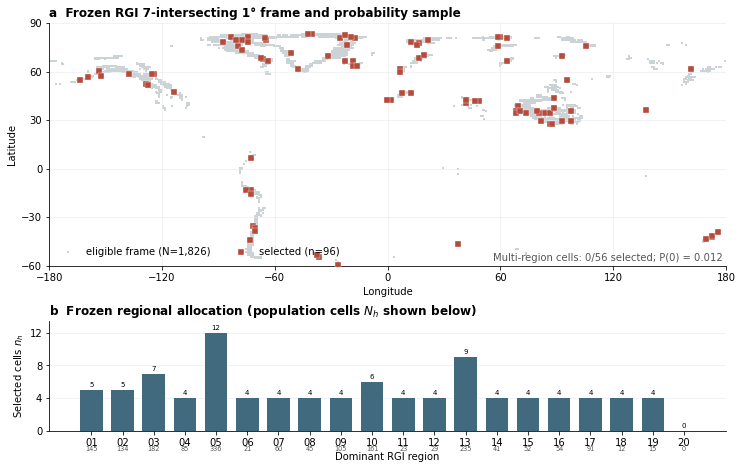

In [3]:
plt.rcParams.update({'font.size': 9, 'axes.spines.top': False, 'axes.spines.right': False})
fig = plt.figure(figsize=(10.2, 6.4), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[2.2, 1])
ax = fig.add_subplot(gs[0])
x = np.array([float(r['west'])+.5 for r in randomized]); y = np.array([float(r['south'])+.5 for r in randomized])
sx = np.array([float(r['west'])+.5 for r in sample]); sy = np.array([float(r['south'])+.5 for r in sample])
ax.scatter(x, y, s=7, marker='s', color='#ccd3d7', linewidths=0, label='eligible frame (N=1,826)')
ax.scatter(sx, sy, s=26, marker='s', color='#b44b3b', edgecolor='white', linewidth=.35, label='selected (n=96)', zorder=3)
ax.set(xlim=(-180,180), ylim=(-60,90), xlabel='Longitude', ylabel='Latitude')
ax.set_xticks(np.arange(-180,181,60)); ax.set_yticks(np.arange(-60,91,30)); ax.grid(color='#e4e7e9', linewidth=.5)
ax.legend(frameon=False, loc='lower left', ncol=2); ax.set_title('a  Frozen RGI 7-intersecting 1° frame and probability sample', loc='left', weight='bold')
ax.text(.995,.02,f'Multi-region cells: {multi_sample}/{multi_frame} selected; P(0) = {p_none:.3f}', transform=ax.transAxes, ha='right', color='#555')
bx = fig.add_subplot(gs[1]); regions=[f'{i:02d}' for i in range(1,21)]; counts=[sum(r['selected']=='yes' for r in groups[h]) for h in regions]
pop=[len(groups[h]) for h in regions]; bars=bx.bar(regions, counts, color='#426a7f', width=.72)
for bar,n,N in zip(bars,counts,pop): bx.text(bar.get_x()+bar.get_width()/2,n+.25,f'{n}',ha='center',va='bottom',fontsize=7)
bx.set(ylim=(0,13.5), xlabel='Dominant RGI region', ylabel='Selected cells $n_h$', yticks=[0,4,8,12])
bx.grid(axis='y', color='#e4e7e9', linewidth=.5); bx.set_axisbelow(True)
bx.set_title('b  Frozen regional allocation (population cells $N_h$ shown below)', loc='left', weight='bold')
for i,N in enumerate(pop): bx.text(i,-1.8,str(N),ha='center',va='top',fontsize=6.5,clip_on=False,color='#555')
fig.savefig(root/'figures/geographic_probability_sample.png', dpi=300, bbox_inches='tight')
fig.savefig(root/'figures/geographic_probability_sample.pdf', bbox_inches='tight')
plt.show()